In [300]:
from datetime import datetime
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.linalg import expm
from scipy.linalg import expm, circulant
import scipy.sparse as sp

In [261]:
def spectral_expansion(v,N):
    # N is number of points I want to map to
    ## vv is the coefficients associated with wavelengths from a lower spatial resolution
    vlen = int(len(v)/2)
    v_expanded = np.zeros(N, dtype=complex)
    v_expanded[:(vlen)] = v[:(vlen)]
    v_expanded[-(vlen):] = v[-(vlen):]
    return v_expanded

In [262]:


def ks_equation(N, h = 1/4):
    
    time_start = time.time()
    x = 32 * np.pi * np.arange(1, N+1) / N
    u = np.cos(x/16) * (1 + np.sin(x/16))
    v = np.fft.fft(u)

    # Precompute various ETDRK4 scalar quantities
    h = 1/4  # time step
    k = np.concatenate([ np.arange(0, N//2), [0], np.arange(-N//2+1, 0)]) / 16  # wave numbers
    L = k**2 - k**4  # Fourier multipliers
    E = np.exp(h * L)
    E2 = np.exp(h * L / 2)
    M = 16  # number of points for complex means
    r = np.exp(1j * np.pi * (np.arange(1, M+1) - 0.5) / M)  # roots of unity

    LR = h * L[:, None] + r[None, :]
    Q = h * np.real(np.mean((np.exp(LR / 2) - 1) / LR, axis=1))
    f1 = h * np.real(np.mean((-4 - LR + np.exp(LR) * (4 - 3 * LR + LR**2)) / LR**3, axis=1))
    f2 = h * np.real(np.mean((2 + LR + np.exp(LR) * (-2 + LR)) / LR**3, axis=1))
    f3 = h * np.real(np.mean((-4 - 3 * LR - LR**2 + np.exp(LR) * (4 - LR)) / LR**3, axis=1))

    # Main time-stepping loop
    uu = u
    vv = v


    tt = [0]
    tmax = 150
    nmax = round(tmax / h)
    nplt = max(1,int(np.floor(nmax / 100)))
    g = -0.5j * k





    for n in range(1, nmax+1):
        t = n * h
        Nv = g * np.fft.fft(np.real(np.fft.ifft(v))**2)
        a = E2 * v + Q * Nv
        Na = g * np.fft.fft(np.real(np.fft.ifft(a))**2)
        b = E2 * v + Q * Na
        Nb = g * np.fft.fft(np.real(np.fft.ifft(b))**2)
        c = E2 * a + Q * (2 * Nb - Nv)
        Nc = g * np.fft.fft(np.real(np.fft.ifft(c))**2)
        
        v = E * v + Nv * f1 + 2 * (Na + Nb) * f2 + Nc * f3
        
        if n % nplt == 0:
            u = np.real(np.fft.ifft(v))
            uu = np.vstack([uu, u])

            vv = np.vstack([vv, v])
            tt.append(t)
    
    time_end = time.time()
    elapsed_time = time_end - time_start
    print(f"KS equation simulation completed in {elapsed_time:.2f} seconds.")
    
    
    return [x, tt, uu, vv, elapsed_time]

In [263]:
def ETDFDM_KS(N,h = 1/4):
    time_start = time.time()

    ##FDM quantities
    ##Discretise space:
    x = 32*np.pi*np.arange(1,N+1)/N
    dx = x[1] - x[0]
    ##set initial conditions
    u = np.cos(x/16) * (1 + np.sin(x/16))
    ## Differentiation matrices plus identity:
    D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

    D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

    D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

    D1[0,-1] = -1
    D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
    D4[-1,0] = D4[0,-1] = -4

    D1 = D1/(2*dx)
    D2 = D2/(dx**2)
    D4 = D4/(dx**4)
    print("Linear operator constructed. Computing ETD-RK4 coefficients...")

    I = np.eye(N)
    ##Linear operator L:
    L = -(D2+D4)

    ##ETD quantities

    M = 64

    r = 15 * np.exp(1j *2* np.pi * (np.arange(1, M+1) - 0.5) / M)

    A = h * L
    E = expm(A)
    E2 = expm(A / 2)

    I = np.eye(N)
    Z = np.zeros((N, N))

    f1 = Z.copy()
    f2 = Z.copy()
    f3 = Z.copy()
    Q  = Z.copy()
    print("Computing ETD-RK4 coefficients...")
    for j in range(M):
        z = r[j]
        zIA = np.linalg.inv(z * I - A)
        
        Q  = Q + h * zIA * (np.exp(z/2) - 1)
        f1 = f1 + h * zIA * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
        f2 = f2 + h * zIA * (2 + z + np.exp(z)*(z - 2)) / z**2
        f3 = f3 + h * zIA * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

    Q  = np.real(Q)/M
    f1 = np.real(f1)/M
    f2 = np.real(f2)/M
    f3 = np.real(f3)/M
    if np.any(np.isnan(Q)) or np.any(np.isnan(f1)) or np.any(np.isnan(f2)) or np.any(np.isnan(f3)):
        print(f"NaN encountered at in setup; stopping time-stepping.")
        return [x, [0], u.reshape(-1, 1), 0]
    if np.any(np.isinf(Q)) or np.any(np.isinf(f1)) or np.any(np.isinf(f2)) or np.any(np.isinf(f3)):
        print(f"Inf encountered at in setup; stopping time-stepping.")
        return [x, [0], u.reshape(-1, 1), 0]



    print("ETD-RK4 coefficients computed. Starting time-stepping...")
    print("E eigenvalues:", np.max(np.abs(np.linalg.eigvalsh(E))))
    print("Q max value:", np.max(np.abs(Q)))
    print("E2 max value:", np.max(np.abs(E2)))
    print("Any NaNs in Q?", np.any(np.isnan(Q)))
    

    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    tmax = 150
    nmax = round(tmax / h)
    nplt = max(1,int(np.floor((tmax / 100) / h)))

    for n in range(1, nmax + 1):
        #print("n = ", n)
        t = n * h

        Nu = -u*(D1@u)
        a  = E2 @ u + Q @ Nu
        Na = -a*(D1@a)

        b  = E2 @ u + Q @ Na
        Nb = -b*(D1@b)
        
        c  = E2 @ a + Q @ (2*Nb - Nu)
        Nc = -c*(D1@c)
        if np.any(np.isnan(a)) or np.any(np.isnan(b)) or np.any(np.isnan(c)):
            print(f"NaN encountered at step {n}, t={t:.6g}; stopping time-stepping.")
            break
        if np.any(np.isinf(a)) or np.any(np.isinf(b)) or np.any(np.isinf(c)):
            print(f"Inf encountered at step {n}, t={t:.6g}; stopping time-stepping.")
            break


        u = E @ u + f1 @ Nu + 2*f2 @ (Na + Nb) + f3 @ Nc

        if n % nplt == 0:
            #print("Saving at t = ", t)
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)
            if n%(10*nplt) == 0:
                print("you have completed", n/nmax)
            
    time_end = time.time()
    time_elapsed = time_end - time_start
    print(f"ETD_KS execution time: {time_elapsed} seconds")

    return [x, tt, uu, time_elapsed]

In [264]:
def Finite_KS(N,mu):

    ##ut = -u*ux - uxx - uxxxx
    ##u_n+1 = u_n + h*(-u_n*ux_n - uxx_n - uxxxx_n)
    ##u_n+1 = u_n + h*(-u_n*D1@u_n - D2@u_n - D4@u_n)
    ##Forward Euler scheme for KS equation with periodic BCs
    ##FDM quantities
    ##Discretise space:
    x = 32*np.pi*np.arange(1,N+1)/N
    dx = x[1] - x[0]
    ##set initial conditions
    u = np.cos(x/16) * (1 + np.sin(x/16))
    ## Differentiation matrices plus identity:
    D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

    D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

    D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

    D1[0,-1] = -1
    D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
    D4[-1,0] = D4[0,-1] = -4

    D1 = D1/(2*dx)
    D2 = D2/(dx**2)
    D4 = D4/(dx**4)

    h = (dx**4) * mu
    tmax = 150
    nmax = round(tmax / h)
    nplt = max(1,int(np.floor(nmax / 100)))
    print(nplt)
    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    for i in range(1, nmax + 1):
        t = i * h
        u = u + h*(-u*(D1@u) - D2@u - D4@u)

        if i % nplt == 0:
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)  
            if i%(nplt*10) == 0:
                print(i/(nmax), "done")

    return [x, tt, uu]


In [265]:
N = 2**6
x,tt,uu,vv,elapsed_time = ks_equation(N, h =1/16)

KS equation simulation completed in 0.03 seconds.


In [266]:
uu.shape

(101, 64)

In [267]:
##ks_equation ie/ the spectral on is vstack, others are hstack, Transposing a hstack turns it into a vstack.

In [268]:
## checking convergence rate of ETDRK4 scheme
## High accuracy solution for refrence N = 2**15
Test_solution = ks_equation(2**14)
x = Test_solution[0]
tt = Test_solution[1]
uu = Test_solution[2]
vv = Test_solution[3]
elapsed_time = Test_solution[4]

KS equation simulation completed in 1.47 seconds.


In [269]:
Number_of_Spatial_Points = 2**np.arange(7,10,1)
Solutions_ETD = []
Solutions_Euler = []


for N in Number_of_Spatial_Points:
    print(f"Computing solution for N = {N}...")
    x, tt, uu, elapsed_time = ETDFDM_KS(N)
    Solutions_ETD.append(uu)
    #x, tt, uu = Finite_KS(N,0.1)
    #Solutions_Euler.append(uu)
    
    

Computing solution for N = 128...
Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...
ETD-RK4 coefficients computed. Starting time-stepping...
E eigenvalues: 1.0640956205708363
Q max value: 0.08050830880975568
E2 max value: 0.48987439502146946
Any NaNs in Q? False
you have completed 0.1
you have completed 0.2
you have completed 0.3
you have completed 0.4
you have completed 0.5
you have completed 0.6
you have completed 0.7
you have completed 0.8
you have completed 0.9
you have completed 1.0
ETD_KS execution time: 0.27022528648376465 seconds
Computing solution for N = 256...
Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...
ETD-RK4 coefficients computed. Starting time-stepping...
E eigenvalues: 1.0642516465145884
Q max value: 0.03355333539707042
E2 max value: 0.2216589085169238
Any NaNs in Q? False
you have completed 0.1
you have completed 0.2
you have completed 0.3
you have completed 0.4
you have

In [270]:

best_etd = Solutions_ETD[-1]


In [271]:
best_etd.shape

(512, 101)

In [272]:
def x_coords(N):
    return 32 * np.pi * np.arange(1, N+1) / N

In [273]:
def t_coords_euler(N):
    h = (32*np.pi/N)**4 * 0.1
    tt = np.array([0.0])
    tmax = 150
    nmax = round(tmax / h)
    nplt = max(int(np.floor((tmax / 100) / h)), 1)
    for i in range(1, nmax + 1):
        if i % nplt == 0:
            tt = np.append(tt, i * h)
    return tt

In [274]:
def t_coords_etd(N):
    h = 1/4
    tt = np.array([0.0])
    tmax = 150
    nmax = round(tmax / h)
    nplt = max(int(np.floor((tmax / 100) / h)), 1)
    for i in range(1, nmax + 1):
        if i % nplt == 0:
            tt = np.append(tt, i * h)
    return tt

Fact: All methods with the same number of points have the same spatial grids.

In [275]:
worst_etd = Solutions_ETD[0]


In [276]:
worst_etd.shape

(128, 101)

In [277]:
uu.shape

(512, 101)

In [380]:
## checking convergence rate of ETDRK4 scheme
## High accuracy solution for refrence N = 2**15
Test_solution = ks_equation(2**14, h = 1/4)
x = Test_solution[0]
tt = Test_solution[1]
uu = Test_solution[2]
vv = Test_solution[3]
elapsed_time = Test_solution[4]

KS equation simulation completed in 1.48 seconds.


In [378]:
x1,t1,u1,time1 = ETDFDM_KS(2**12, h = 1/4)

Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...
ETD-RK4 coefficients computed. Starting time-stepping...
E eigenvalues: 1.0642953417685161
Q max value: 0.002023647900408383
E2 max value: 0.013544485009348602
Any NaNs in Q? False
you have completed 0.1
you have completed 0.2
you have completed 0.3
you have completed 0.4
you have completed 0.5
you have completed 0.6
you have completed 0.7
you have completed 0.8
you have completed 0.9
you have completed 1.0
ETD_KS execution time: 276.0412995815277 seconds


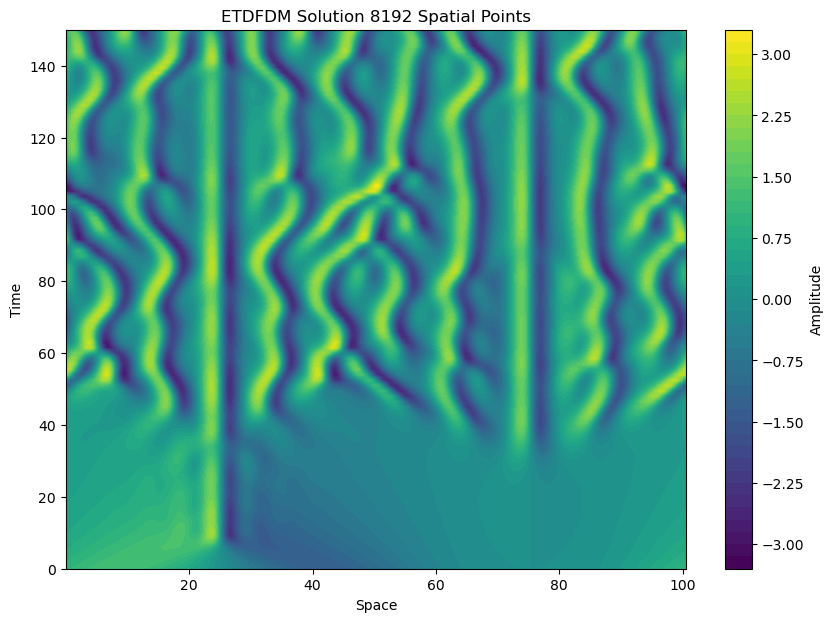

In [292]:

fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x1, t1)
contour = ax.contourf(X, T, u1.T, levels=50, cmap=cm.viridis)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Amplitude')

# Set labels and title
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('ETDFDM Solution 4096 Spatial Points')

plt.show()

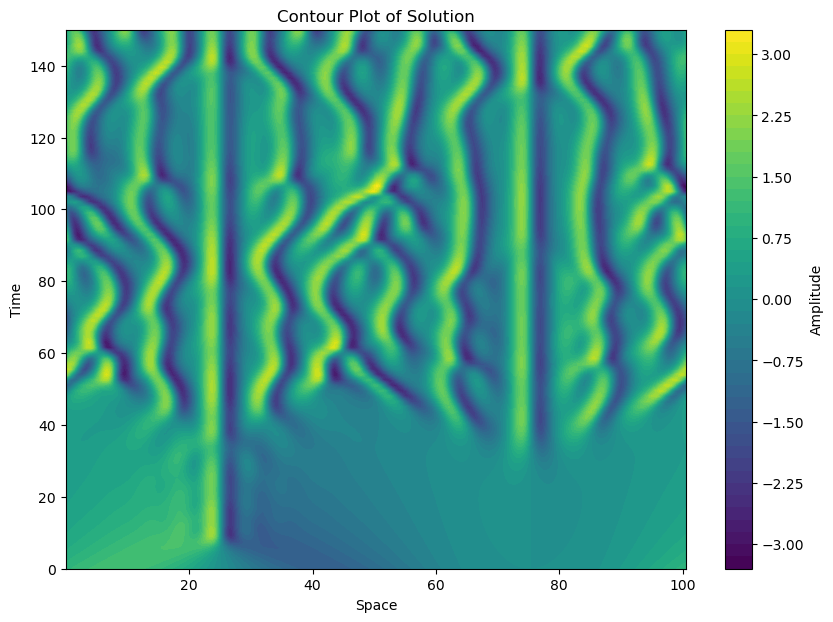

In [293]:

fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x, tt)
contour = ax.contourf(X, T, uu, levels=50, cmap=cm.viridis)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Amplitude')

# Set labels and title
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('Contour Plot of Solution')

plt.show()

C:\Users\Eleph\AppData\Local\Temp\ipykernel_20392\2214541066.py:5: RuntimeWarning: divide by zero encountered in log
  contour = ax.contourf(X, T, np.log(np.abs(uu[:,2**(14-12)-1::2**(14-12)]-u1.T)), levels=50, cmap=cm.viridis)


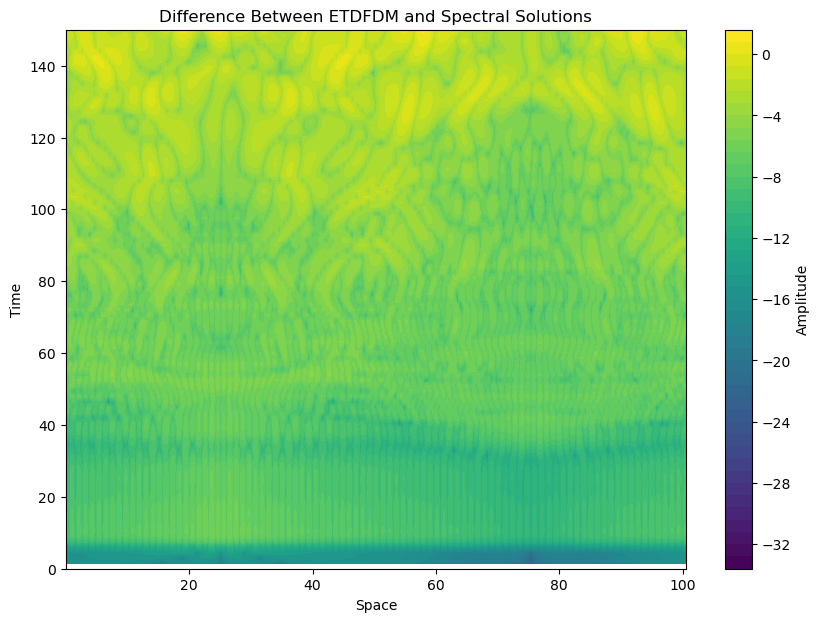

In [405]:
##plot reference solution at final time, contour plot of solution in space and time, plot of solution at final time

fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x1,t1)
contour = ax.contourf(X, T, np.log(np.abs(uu[:,2**(14-12)-1::2**(14-12)]-u1.T)), levels=50, cmap=cm.viridis)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Amplitude')

# Set labels and title
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('Difference Between ETDFDM and Spectral Solutions')

plt.show()

C:\Users\Eleph\AppData\Local\Temp\ipykernel_20392\3331731263.py:5: RuntimeWarning: divide by zero encountered in log
  contour = ax.contourf(X, T, np.log(np.abs(uu[:,2**(14-12)-1::2**(14-12)]-u2.T)), levels=50, cmap=cm.viridis)


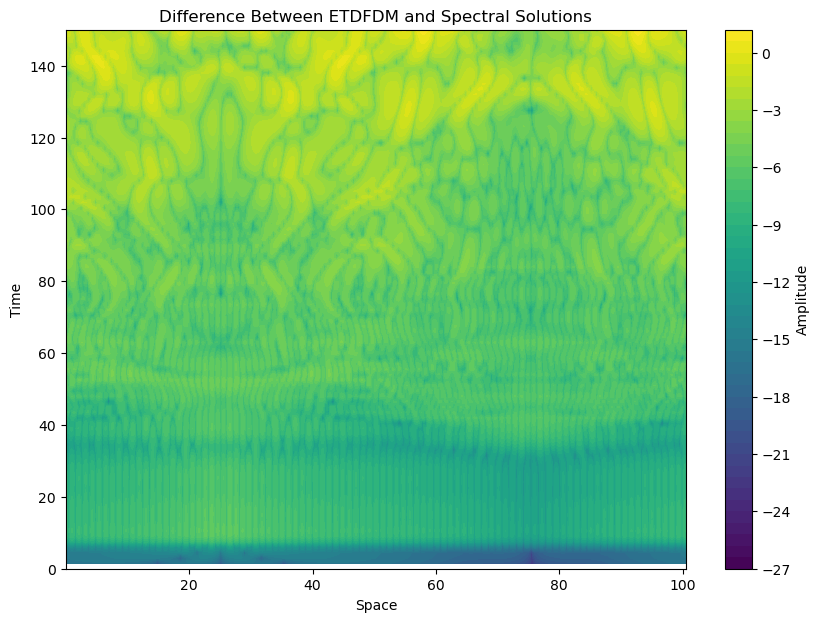

In [407]:
##plot reference solution at final time, contour plot of solution in space and time, plot of solution at final time

fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x2,t2)
contour = ax.contourf(X, T, np.log(np.abs(uu[:,2**(14-12)-1::2**(14-12)]-u2.T)), levels=50, cmap=cm.viridis)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Amplitude')

# Set labels and title
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('Difference Between ETDFDM and Spectral Solutions')

plt.show()

In [297]:
# ...existing code...
def circulant_inverse_from_Aeig(z, lamA, tol=1e-12):
    """
    Return (zI - A)^(-1) for circulant A using FFT eigenvalues lamA = fft(first_col(A)).
    """
    denom = z - lamA
    if np.any(np.abs(denom) < tol):
        raise np.linalg.LinAlgError("zI - A is (near) singular for this contour point.")
    inv_first_col = np.fft.ifft(1.0 / denom)
    return circulant(inv_first_col)
# ...existing code...

In [314]:
def ETDFDM_KS_FFT(N,h = 1/4):
    time_start = time.time()

    ##FDM quantities
    ##Discretise space:
    x = 32*np.pi*np.arange(1,N+1)/N
    dx = x[1] - x[0]
    ##set initial conditions
    u = np.cos(x/16) * (1 + np.sin(x/16))
    ## Differentiation matrices plus identity:
    D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

    D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

    D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

    D1[0,-1] = -1
    D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
    D4[-1,0] = D4[0,-1] = -4

    D1 = D1/(2*dx)
    D2 = D2/(dx**2)
    D4 = D4/(dx**4)
    print("Linear operator constructed. Computing ETD-RK4 coefficients...")

    I = np.eye(N)
    ##Linear operator L:
    L = -(D2+D4)

    ##ETD quantities

    M = 64

    r = 15 * np.exp(1j *2* np.pi * (np.arange(1, M+1) - 0.5) / M)

    A = h * L
    
    # FFT eigenvalues of circulant A
    A_first_col = A[:, 0].astype(complex)
    lamA = np.fft.fft(A_first_col)
    
    E = np.real(circulant(np.fft.ifft(np.exp(lamA))))
    E2 = np.real(circulant(np.fft.ifft(np.exp(lamA / 2))))
    
    

    
    Z = np.zeros((N, N))

    f1 = Z.copy()
    f2 = Z.copy()
    f3 = Z.copy()
    Q  = Z.copy()
    print("Computing ETD-RK4 coefficients...")
    for j in range(M):
        z = r[j]
        
        zIA = circulant_inverse_from_Aeig(z, lamA)
        
        Q  = Q + h * zIA * (np.exp(z/2) - 1)
        f1 = f1 + h * zIA * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
        f2 = f2 + h * zIA * (2 + z + np.exp(z)*(z - 2)) / z**2
        f3 = f3 + h * zIA * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

    Q  = np.real(Q)/M
    f1 = np.real(f1)/M
    f2 = np.real(f2)/M
    f3 = np.real(f3)/M
    if np.any(np.isnan(Q)) or np.any(np.isnan(f1)) or np.any(np.isnan(f2)) or np.any(np.isnan(f3)):
        print(f"NaN encountered at in setup; stopping time-stepping.")
        return [x, [0], u.reshape(-1, 1), 0]
    if np.any(np.isinf(Q)) or np.any(np.isinf(f1)) or np.any(np.isinf(f2)) or np.any(np.isinf(f3)):
        print(f"Inf encountered at in setup; stopping time-stepping.")
        return [x, [0], u.reshape(-1, 1), 0]



    print("ETD-RK4 coefficients computed. Starting time-stepping...")
    print("E eigenvalues:", np.max(np.abs(np.linalg.eigvalsh(E))))
    print("Q max value:", np.max(np.abs(Q)))
    print("E2 max value:", np.max(np.abs(E2)))
    print("Any NaNs in Q?", np.any(np.isnan(Q)))
    

    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    tmax = 150
    nmax = round(tmax / h)
    nplt = max(1,int(np.floor((tmax / 100) / h)))

    for n in range(1, nmax + 1):
        #print("n = ", n)
        t = n * h

        Nu = -u*(D1@u)
        a  = E2 @ u + Q @ Nu
        Na = -a*(D1@a)

        b  = E2 @ u + Q @ Na
        Nb = -b*(D1@b)
        
        c  = E2 @ a + Q @ (2*Nb - Nu)
        Nc = -c*(D1@c)
        if np.any(np.isnan(a)) or np.any(np.isnan(b)) or np.any(np.isnan(c)):
            print(f"NaN encountered at step {n}, t={t:.6g}; stopping time-stepping.")
            break
        if np.any(np.isinf(a)) or np.any(np.isinf(b)) or np.any(np.isinf(c)):
            print(f"Inf encountered at step {n}, t={t:.6g}; stopping time-stepping.")
            break


        u = E @ u + f1 @ Nu + 2*f2 @ (Na + Nb) + f3 @ Nc

        if n % nplt == 0:
            #print("Saving at t = ", t)
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)
            if n%(10*nplt) == 0:
                print("you have completed", n/nmax)
            
    time_end = time.time()
    time_elapsed = time_end - time_start
    print(f"ETD_KS execution time: {time_elapsed} seconds")

    return [x, tt, uu, time_elapsed]

In [335]:
def ETDFDM_KS_FFT2(N,h = 1/4):
    time_start = time.time()

    ##FDM quantities
    ##Discretise space:
    x = 32*np.pi*np.arange(1,N+1)/N
    dx = x[1] - x[0]
    ##set initial conditions
    u = np.cos(x/16) * (1 + np.sin(x/16))
    ## Differentiation matrices plus identity:
    D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

    D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

    D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

    D1[0,-1] = -1
    D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
    D4[-1,0] = D4[0,-1] = -4

    D1 = D1/(2*dx)
    D2 = D2/(dx**2)
    D4 = D4/(dx**4)
    print("Linear operator constructed. Computing ETD-RK4 coefficients...")

    I = np.eye(N)
    ##Linear operator L:
    L = -(D2+D4)

    ##ETD quantities

    M = 64

    r = 15 * np.exp(1j *2* np.pi * (np.arange(1, M+1) - 0.5) / M)

    A = h * L
    
    # FFT eigenvalues of circulant A
    a_eigs = np.fft.fft(A[:,0].astype(complex))
    D1_eigs = np.fft.fft(D1[:,0].astype(complex))

    
    E_eigs  = np.real(np.exp(a_eigs))
    E2_eigs = np.real(np.exp(a_eigs / 2))

    
    Q_eigs  = np.zeros(N, dtype=complex)
    f1_eigs = np.zeros(N, dtype=complex)
    f2_eigs = np.zeros(N, dtype=complex)
    f3_eigs = np.zeros(N, dtype=complex)
    print("Computing ETD-RK4 coefficients...")
    for j in range(M):
        z = r[j]
        d = 1.0 / (z - a_eigs)          # eigenvalues of (zI - A)^{-1}, shape (N,)

        Q_eigs  += h * d * (np.exp(z/2) - 1)
        f1_eigs += h * d * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
        f2_eigs += h * d * (2 + z + np.exp(z)*(z - 2)) / z**2
        f3_eigs += h * d * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

    Q_eigs  = np.real(Q_eigs)  / M
    f1_eigs = np.real(f1_eigs) / M
    f2_eigs = np.real(f2_eigs) / M
    f3_eigs = np.real(f3_eigs) / M


    def circ_matvec(eigs, v):
        return np.real(np.fft.ifft(eigs * np.fft.fft(v)))


    

    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    tmax = 150
    nmax = round(tmax / h)
    nplt = max(1,int(np.floor((tmax / 100) / h)))

    for n in range(1, nmax + 1):
        t = n * h
        
        
        
        Nu = -u * circ_matvec(D1_eigs, u)
        a  = circ_matvec(E2_eigs, u)  + circ_matvec(Q_eigs,  Nu)
        Na = -a * circ_matvec(D1_eigs, a)

        b  = circ_matvec(E2_eigs, u)  + circ_matvec(Q_eigs,  Na)
        Nb = -b * circ_matvec(D1_eigs, b)

        c  = circ_matvec(E2_eigs, a)  + circ_matvec(Q_eigs,  2*Nb - Nu)
        Nc = -c * circ_matvec(D1_eigs, c)

        u  = circ_matvec(E_eigs, u) + circ_matvec(f1_eigs, Nu) \
           + 2*circ_matvec(f2_eigs, Na + Nb) + circ_matvec(f3_eigs, Nc)

        if n % nplt == 0:
            #print("Saving at t = ", t)
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)
            if n%(10*nplt) == 0:
                print("you have completed", n/nmax)
            
    time_end = time.time()
    time_elapsed = time_end - time_start
    print(f"ETD_KS execution time: {time_elapsed} seconds")

    return [x, tt, uu, time_elapsed]

In [376]:
x2,t2,u2,time2 = ETDFDM_KS_FFT(2**12, h = 1/4)

Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...
ETD-RK4 coefficients computed. Starting time-stepping...
E eigenvalues: 1.064295339485486
Q max value: 0.0020236479001778072
E2 max value: 0.013544484993750005
Any NaNs in Q? False
you have completed 0.1
you have completed 0.2
you have completed 0.3
you have completed 0.4
you have completed 0.5
you have completed 0.6
you have completed 0.7
you have completed 0.8
you have completed 0.9
you have completed 1.0
ETD_KS execution time: 138.7181887626648 seconds


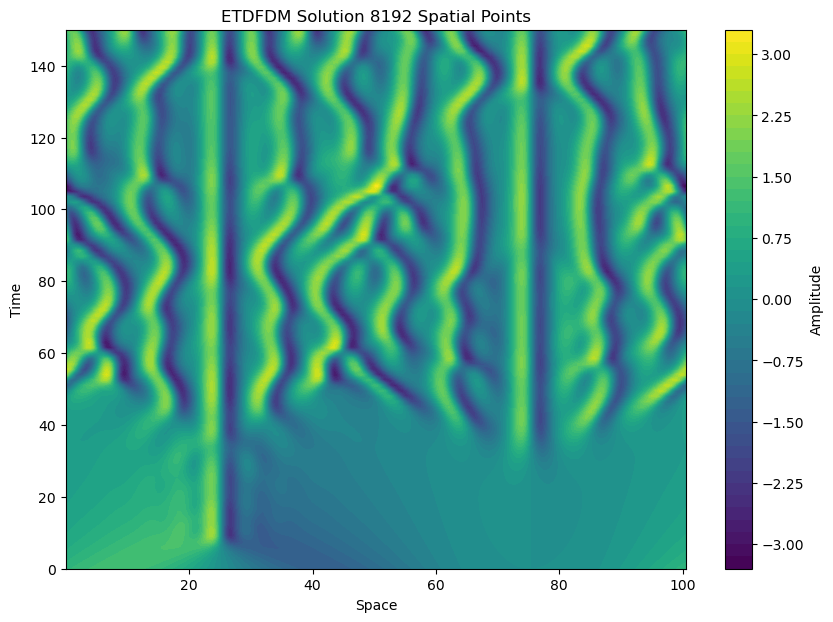

In [369]:

fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x2, t2)
contour = ax.contourf(X, T, u2.T, levels=50, cmap=cm.viridis)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Amplitude')

# Set labels and title
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('ETDFDM Solution 8192 Spatial Points')

plt.show()

In [397]:
N = 5
D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

D1[0,-1] = -1
D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
D4[-1,0] = D4[0,-1] = -4

In [398]:
A = D2 + D4

Aexp_default = expm(A)

Aexp_fft = np.real(circulant(np.fft.ifft(np.exp(np.fft.fft(A[:,0])))))

In [403]:
np.max(np.abs(Aexp_default - Aexp_fft))

np.float64(1.9463186617940664e-10)

In [400]:
Aexp_fft

array([[ 5197.9218201 , -4204.08712001,  1605.62620996,  1605.62620996,
        -4204.08712001],
       [-4204.08712001,  5197.9218201 , -4204.08712001,  1605.62620996,
         1605.62620996],
       [ 1605.62620996, -4204.08712001,  5197.9218201 , -4204.08712001,
         1605.62620996],
       [ 1605.62620996,  1605.62620996, -4204.08712001,  5197.9218201 ,
        -4204.08712001],
       [-4204.08712001,  1605.62620996,  1605.62620996, -4204.08712001,
         5197.9218201 ]])

In [404]:
Aexp_default

array([[ 5197.9218201 , -4204.08712001,  1605.62620996,  1605.62620996,
        -4204.08712001],
       [-4204.08712001,  5197.9218201 , -4204.08712001,  1605.62620996,
         1605.62620996],
       [ 1605.62620996, -4204.08712001,  5197.9218201 , -4204.08712001,
         1605.62620996],
       [ 1605.62620996,  1605.62620996, -4204.08712001,  5197.9218201 ,
        -4204.08712001],
       [-4204.08712001,  1605.62620996,  1605.62620996, -4204.08712001,
         5197.9218201 ]])